
# ICS - Travaux Pratiques 8

16.04.25


<font color=grey>_Ce 8e TP est axé autour de la compréhension des algorithmes, et de ce qui qualifie un bon algorithme. Nous en profiterons pour réviser la représentation gaphique d'objets en Matplotlib et (enfin) utiliser nos connaissances en Python pour écrire des algorithmes fonctionnels. Bien que cette série soit sous forme de Jupyter Notebook, vous devrez résoudre une partie des exercices sur papier._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

***

## Exercice 0 : Echauffement

On donne l'algorithme suivant :

1
4
0


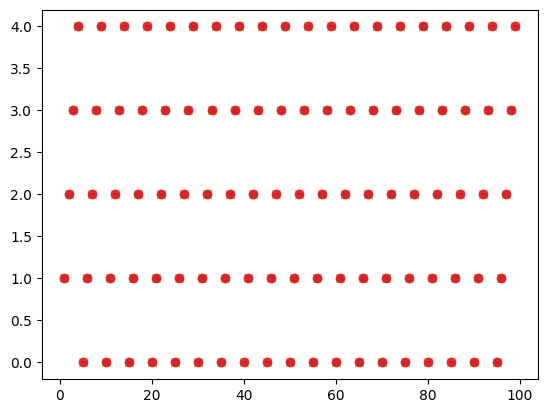

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def f(a, b):
    """
    Input : a, b entiers , a >= b > 0
    """
    r = a
    k = 0
    while r >= b:
        r -= b
        k += 1
    return r

print(f(3,2), f(20, 16), f(20, 5), sep="\n")

markers = [".", "x", ",", "o"] # se superposent, donc ont toujours les mêmes valeurs
b = [1, 5, 200, 12]

for i in range(4):
    a, b = np.arange(1, 100), np.full(100, b[i])
    r = [f(ai, 5) for ai in a]

    plt.plot(a, r, marker=markers[i], linewidth=0, markevery=1)

plt.show()

1. **Sans exécuter le code**, donner la valeur de `f(3,2)`, `f(20,16)`, `f(20,5)`. Vérifiez ensuite en faisant tourner le code.

2. Que calcule cet algorithme? (return r, le reste de $\frac{a}{b}$ et k donne a % b)

3. Comme évolue le temps de parcours `T` en fonction de l'argument `a` donné en entrée? On suppose que `b`reste fixe. (O(2 + 2 $\cdot$ a%b + 1) ~ O(a%b) ~ O(n))

***

## Exercice 1 : Complexité

1. Ordonnez sans justification les fonctions suivantes par ordre de croissance, c'est-à-dire pour deux fonctions données $f$ et $g$, faites apparaître $f$ avant $g$ si $f = \mathcal{O}(g)$. Groupez ensemble les fonctions qui ont le même ordre de croissance (c'est-à-dire groupez ensemble $f$ et $g$ si $f = \Theta(g)$).

$$n + 50,\,  n\sqrt{n},\, 2n,\, 100,\, 10n^{0.1},\, n^2,\, n^3 + n^2,\, n^3,\, n^{1.1},\, \left|\sin(n)\right| + 1,\,  n^{10}$$

$$\left|\sin(n)\right| + 1,\, 100,\, 10n^{0.1},\, n\sqrt{n},\, n + 50,\, 2n,\, n^{1.1},\, n^2,\, n^3,\, n^3 + n^2,\, n^{10} -> FAUX$$

Vrai ordre :
$$\left|\sin(n)\right| + 1,\, 10n^{0.1},\, 100,\, n + 50,\, n^{1.1},\, 2n,\, n\sqrt{n},\, n^2,\, n^3,\, n^3 + n^2,\, n^{10}$$

2. Représentez graphiquement chacune de ces fonctions en utilisant la librairie Matplotlib.

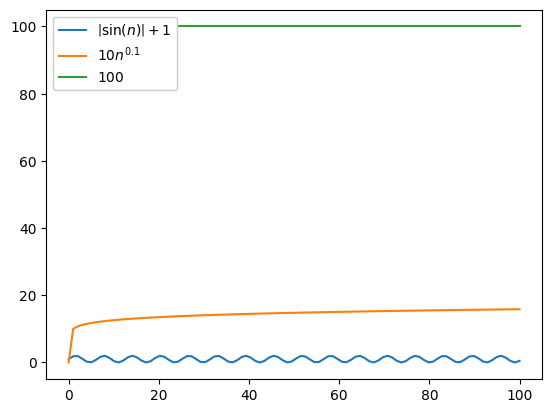

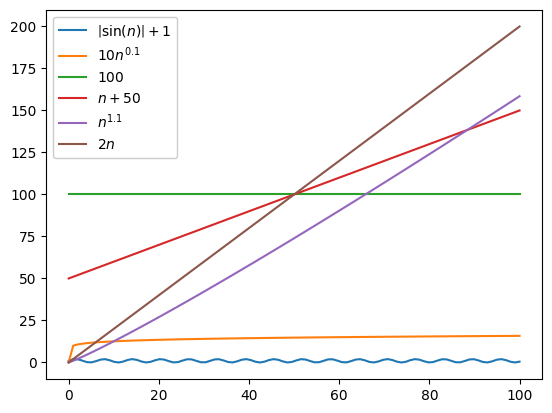

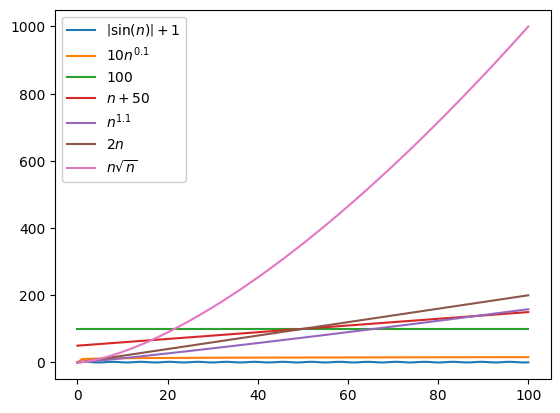

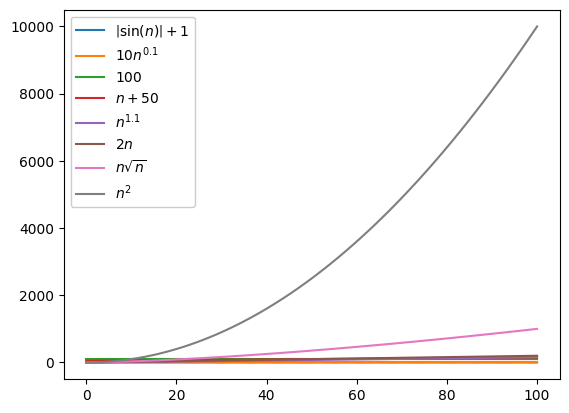

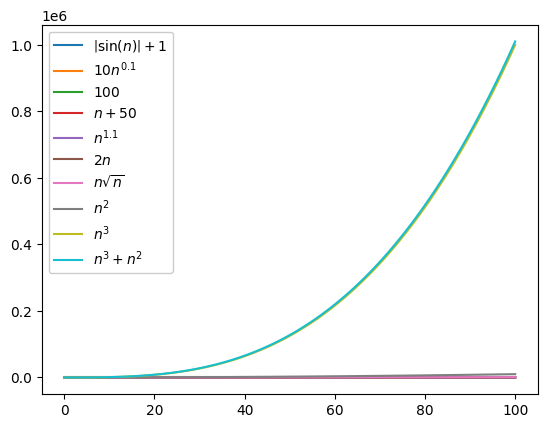

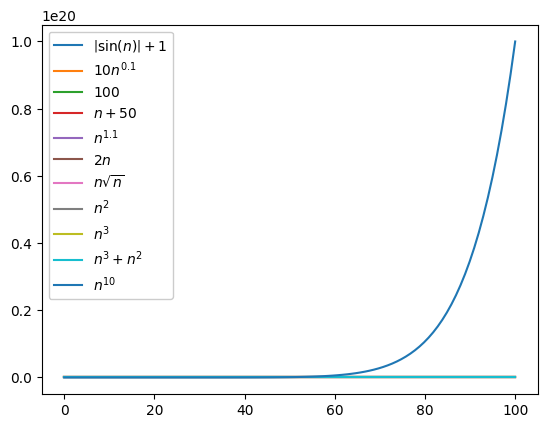

In [66]:
# Réponse au point 2.
nbre = 100

n = np.linspace(0, 100, nbre)
y = np.arange(0, 15, .1)

def o_1():
    plt.plot(n, np.abs(np.sin(n) + 1), label=r"$\left|\sin(n)\right| + 1$")
    plt.plot(n, 10*(n ** 0.1), label=r"$10n^{0.1}$")
    plt.plot(n, np.full(nbre,100), label=r"$100$")


def o_n():
    o_1()
    plt.plot(n, n + 50, label=r"$n + 50$")
    plt.plot(n, n ** 1.1, label=r"$n^{1.1}$")
    plt.plot(n, 2*n, label=r"$2n$")


def o_n1_2():
    o_n()
    plt.plot(n, n * np.sqrt(n), label=r"$n\sqrt{n}$")


def o_n2():
    o_n1_2()
    plt.plot(n, n ** 2, label=r"$n^2$")


def o_n3():
    o_n2()
    plt.plot(n, n ** 3, label=r"$n^3$")
    plt.plot(n, n ** 3 + n ** 2, label=r"$n^3 + n^2$")


def o_n10():
    o_n3()
    plt.plot(n, n ** 10, label=r"$n^{10}$")


o_1()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n1_2()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n2()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n3()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n10()
plt.legend(loc="upper left", framealpha=1)
plt.show()

***

## Exercice 2 : Notation de Landau

Pour $n \in \N$, prouvez les affirmations suivantes en exhibant une constante $C$ (ou des constantes $C_1$ et $C_2$) et un rang $N$ appropriés:

1. $2n + 100 = \Theta(n)$

2. $an + b = \Theta(n)$ pour $a, b$ des réels strictement positifs

3. $100n\sqrt{n} = \mathcal{O}(n^2)$.
     

***

## Exercice 3 : Notation de Landau

1. Soit $n \in \N$, et $f, g, h$ des fonctions positives de $n$ telles que $f = \mathcal{O}(g)$ et $g = \mathcal{O}(h)$. Prouvez que $f = \mathcal{O}(h)$.

2. Soient $T'(n)$ et $T''(n)$ les temps de parcours respectifs des algorithmes `max_somme` et `max_somme_lineaire` tels qu'ils ont été définis au cours. Déduisez du point 1. que $T''(n) = \mathcal{O}(T'(n))$.

***

## Exercice 4 : révision d'algorithme

Reprenons l'exercice 5 de la série 3. Le point 1. est optionnel, mais peut être utile pour vous rafraichir la mémoire!

1. Donnez un algorithme `carre` qui prend un entier positif $n$ en entrée et affiche un carré de côté $n$. Par exemple, l'appel   `carre(5)` doit afficher:

    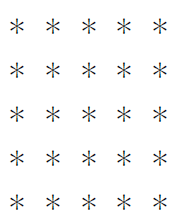
							
L'espaçage entre les astérisques n'est pas important.

2. Combien d'astérisques est-ce que votre code affiche, pour l'entrée $n$? ($5 \cdot 5 = 25$) / ($\frac{5 \cdot (5 + 1)}{2} = 15$)

3. Donnez, en notation $\Theta(\cdot)$, l'ordre de croissance du temps de parcours de votre algorithme en fonction de $n$. ($\Theta(n^2)$) / ($\Theta(n^2)$)

<font color=grey>**Remarque**: si votre algorithme contient des instructions de la forme `print("*" * i)`,  sachez qu'une telle instruction ne prend pas temps constant! En effet la création et le stockage en mémoire d'une chaîne de caractère de taille $n$ prendra un temps (et un espace en mémoire) au moins linéaire en $n$.

Un algorithme contenant deux boucles `for` imbriquées prendra le même temps de parcours mais ce temps de parcours sera plus facile à analyser.</font>

4. Donnez un algorithme `triangle` qui prend un entier positif $n$ en entrée et affiche un triangle de côté $n$ de la forme ci-dessous (dans ce cas, ce triangle a été affiché par `triangle(5)`):
	
	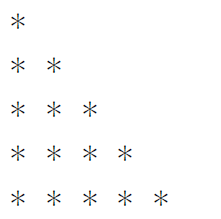
	
	Puis répondez aux mêmes questions 2. et 3. pour l'algorithme `triangle`.

In [8]:
# Réponse au point 1.
def carre(n):
    print(("*"*n+"\n")*n)

carre(5)

*****
*****
*****
*****
*****



In [11]:
# Réponse au point 4
def triangle(m):
    triangle = ""
    for i in range(m):
        triangle += "*"*(i+1)+"\n"
    print(triangle)
    

triangle(5)

*
**
***
****
*****



***

## Exercice 5 : Maximum d'une liste

Soit `L` une liste de $n \geq 3$ nombres. On s'intéresse à la plus grande somme de trois éléments distincts de la liste, c'est-à-dire au maximum de la valeur de `L[i] + L[j] + L[k]`, pour `i, j, k` des indices de `L` distincts deux à deux. 

1. Modifiez chacun des algorithmes `max_somme` et `max_somme_lineaire` vus en cours pour calculer le maximum demandé. Vous devrez réutiliser l'agorithme `max_liste` vu en cours

2. Utilisez le module `time` comme vu en cours pour mesurer le temps de parcours de chacun de vos algorithmes sur une liste de nombre aléatoires dont vous ferez varier la taille. Est-ce que c'est soutenable de donner une liste de taille $1000$ à ces deux algorithmes? Une liste de taille $10'000$?
	
3. Donnez, en notation $\Theta(\cdot)$, l'ordre de croissance du temps de parcours de chacun des deux algorithmes en fonction de la taille de l'entrée.
	
<font color=grey>**Indication**: vous pouvez utiliser les identités $$\sum_{k=1}^n k = \frac{n(n+1)}{2}$$ et 	$$\sum_{k=1}^n k^2 = \frac{n(n+1)(2n+1)}{6}.$$ </font>

In [83]:
# Réponse au point 1. 
def max_liste(L):
    n = len(L)
    max_L = L[0]
    for i in range(1, n):
        if L[i] > max_L:
            max_L = L[i]
    
    return max_L


def max_somme(L): # Théta(n^3)
    '''
    Entree: liste L de nombres de taille n >= 3
    Sortie: Somme maximale de trois elements de L
    '''
    n = len(L)
    max_s = L[0] + L[1] + L[2]
    
    for i in range(n):
        for j in range(i+1, n):
            for k in range(j+1, n):
                if L[i] + L[j] + L[k] > max_s:
                    max_s = L[i] + L[j] + L[k]
    
    return max_s


def max_somme_lineaire(L): # Théta(n)
    '''
    Entree: liste L de nombres de taille n >= 3
    Sortie: Somme maximale de trois elements de L
    '''
    max1 = max_liste(L)
    L.remove(max1)
    max2 = max_liste(L)
    L.remove(max2)
    max3 = max_liste(L)
    
    return max1 + max2 + max3

In [82]:
# Réponse au point 2.
from time import time

len_ = [100, 1000, 10000]
N = 1000
a = np.random.rand(N)

def test(nbres):
    for nbre in nbres:
        L = list(range(nbre))
        
        t0 = time()
        max_somme_lineaire(L)
        t1 = time()
        print(f"L'appel 'max_somme_lineaire({nbre})' a pris ", t1 - t0, " seconde(s).")

        t0 = time()
        max_somme(L)
        t1 = time()
        print(f"L'appel 'max_somme({nbre})' a pris ", t1 - t0, " seconde(s).")
        

test(len_)

L'appel 'max_somme_lineaire(100)' a pris  0.0  seconde(s).
L'appel 'max_somme(100)' a pris  0.06504344940185547  seconde(s).
L'appel 'max_somme_lineaire(1000)' a pris  0.0  seconde(s).
L'appel 'max_somme(1000)' a pris  71.56525945663452  seconde(s).
L'appel 'max_somme_lineaire(10000)' a pris  0.00751185417175293  seconde(s).


KeyboardInterrupt: 

***

## Exercice 6

<font color=greblueen> Chaque semaine, je vous propose un exercice sans corrigé détaillé mais en vous indiquant la réponse finale. Ce sera donc à vous de faire l'effort de résoudre ce problème à l'aide des ressources à disposition : vos notes de cours, les forums sur internet ou même ChatGPT du moment que vous faites l'effort de comprendre le code que vous fournit ce Chatbot! </font>

Cette semaine, nous n'aurons pas d'exercice supplémentaire mais je vous lance quelques pistes de réflexion pour anticiper le cours suivant.

Saurez vous estimer le comportement asymptotique du temps de parcours des méthodes suivantes? N'hésitez pas à représenter graphiquement le temps de parcours $T(n)$ en fonction de la taille de la liste en entrée !
- `pop()` (sans argument) -> $O(1)$
- `pop(i)` (avec argument) -> $O(n)$
- `append()` -> $O(1)$
- `insert(i, x)` -> $O(n-i)$
- `x in L` (chercher si un élément apparait dans une liste) -> $O(n)$
- `len(L)` -> $O(1)$

In [67]:
def mymin(L):
    m = float('inf')
    for i in L:
        if i < m:
            m = i
    return m

L = [5,3,6,7,4,6,7,5]
print(mymin(L))


3


In [68]:
def find_min(L):
    m = []
    for i in range(len(L)):
        m.append(mymin(L[i:]))
    return m 
        
L = [5,3,6,7,4,6,7,5]
print(find_min(L))
        

[3, 3, 4, 4, 4, 5, 5, 5]


In [69]:
def decomposition(N):
    co = 0
    x = N/2
    while x >=1:
        co +=1
        x /= 2
    reste = N-2**co
    return co, reste

out = decomposition(10)
print(out)

(3, 2)
